# EDA - Univariate Analysis

#### what is Univariate Analysis?
Univariate analysis is a statistical technique used to examine and understand one variable at a time.
Univariate analysis = Studying one feature independently to understand its distribution, pattern, and behavior.


### Why Do We Perform Univariate Analysis?


#### Importance of Univariate Analysis

#### What Do We Check in Univariate Analysis?
- For Numerical Variables : 
    Mean , Median,Standard deviation, Min & Max, Range,Skewness,outliers,Distribution shape (normal / skewed)
    Visual tools: Histogram, Boxplot

- For Categorical Variables

    Frequency counts, Percentage distribution,Most/least frequent category, Class imbalance (especially target variable)

Visual tools: Bar plot, Count plot


Univariate analysis is the process of analyzing each variable individually to understand its distribution, characteristics, and potential data issues. It does not examine relationships between variables. It is an essential step in Exploratory Data Analysis (EDA) and helps in identifying missing values, skewness, outliers, and class imbalance. In the Adult dataset, univariate analysis is performed on all 14 features to understand their individual behavior before proceeding to further analysis or model building.



#### 

In [68]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

sns.set(style="whitegrid")

In [69]:
df_train_test = pd.read_csv("df_train_test.csv") 

In [3]:
df_train_test.head()

,age,workclass,fnlwgt,education,education_num,marital_status,occupation,relationship,race,sex,capital_gain,capital_loss,hours_per_week,native_country,income,source,capital_gain_bin,capital_loss_bin,net_capital,income_binary
0,39,State-gov,77516,Bachelors,13,Never-married,Adm-clerical,Not-in-family,White,Male,2174,0,40,United-States,<=50K,train,1,0,2174,0
1,50,Self-emp-not-inc,83311,Bachelors,13,Married-civ-spouse,Exec-managerial,Husband,White,Male,0,0,13,United-States,<=50K,train,0,0,0,0
2,38,Private,215646,HS-grad,9,Divorced,Handlers-cleaners,Not-in-family,White,Male,0,0,40,United-States,<=50K,train,0,0,0,0
3,53,Private,234721,11th,7,Married-civ-spouse,Handlers-cleaners,Husband,Black,Male,0,0,40,United-States,<=50K,train,0,0,0,0
4,28,Private,338409,Bachelors,13,Married-civ-spouse,Prof-specialty,Wife,Black,Female,0,0,40,Cuba,<=50K,train,0,0,0,0


In [ ]:
# Analysis of Capital_gain 

In [13]:
df_train_test['capital_gain'].describe()

count    48813.000000
mean      1079.708705
std       7454.185982
min          0.000000
25%          0.000000
50%          0.000000
75%          0.000000
max      99999.000000
Name: capital_gain, dtype: float64

In [21]:
df_train_test['capital_gain'].skew()

11.891093437953028

<span style="color: blue;"><b> The distribution is heavily right‑skewed </b></span>

In [26]:
# Percentage of zero values (important for gain & loss)
zero_percent = (df_train_test['capital_gain'] == 0).mean() * 100
print(f" % of capital_gain zero values: {zero_percent:.2f}%")

 % of capital_gain zero values: 91.73%


In [27]:
(df_train_test['capital_gain'] == 0).mean()   # proportion of zeros

0.9173375944932702

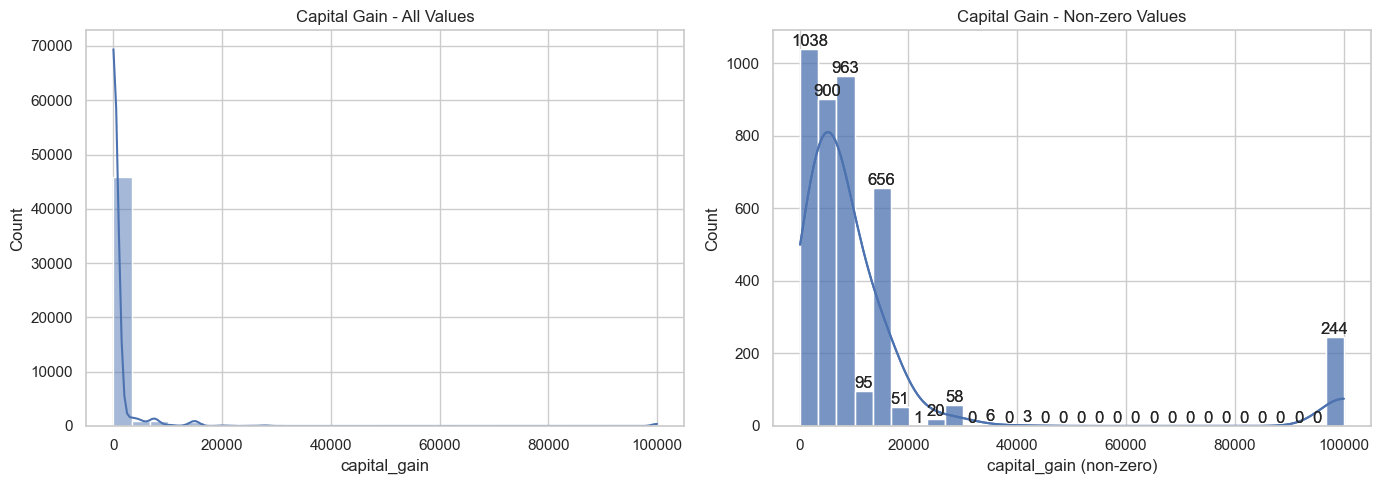

In [32]:
# 2 histogram one for all data and another for non-zero data

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# 1) All data
sns.histplot(df_train_test['capital_gain'], bins=30, kde=True, ax=axes[0], color='#4c72b0')
axes[0].set_title('Capital Gain - All Values')
axes[0].set_xlabel('capital_gain')
axes[0].set_ylabel('Count')

# 2) Non-zero capital gain
non_zero_gain = df_train_test[df_train_test['capital_gain'] > 0]['capital_gain']
ax = sns.histplot(non_zero_gain, bins=30, kde=True, ax=axes[1], color='#4c72b0')
sns.histplot(non_zero_gain, bins=30, kde=True, ax=axes[1])
axes[1].set_title('Capital Gain - Non-zero Values')
axes[1].set_xlabel('capital_gain (non-zero)')
axes[1].set_ylabel('Count')

# Add counts on top of each bar
for container in ax.containers:
    ax.bar_label(container)          # or ax.bar_label(container, fmt='%d')
    
plt.tight_layout()
plt.show()


<span style="color: blue;"><b> Capital gains are zero for the majority of individuals.
Among positive capital gains, amounts are dispersed with a few very large values, indicating an extremely right‑skewed distribution.</b></span>

# Analysis of capital loss

In [34]:
df_train_test['capital_loss'].describe()

count    48813.000000
mean        87.554299
std        403.118605
min          0.000000
25%          0.000000
50%          0.000000
75%          0.000000
max       4356.000000
Name: capital_loss, dtype: float64

In [35]:
df_train_test['capital_loss'].skew()

4.5682632007783495

In [39]:
# Percentage of zero values (important for gain & loss)
zero_percent = (df_train_test['capital_loss'] == 0).mean() * 100
print(f" % of capital_loss zero values: {zero_percent:.2f}%")

 % of capital_loss zero values: 95.33%


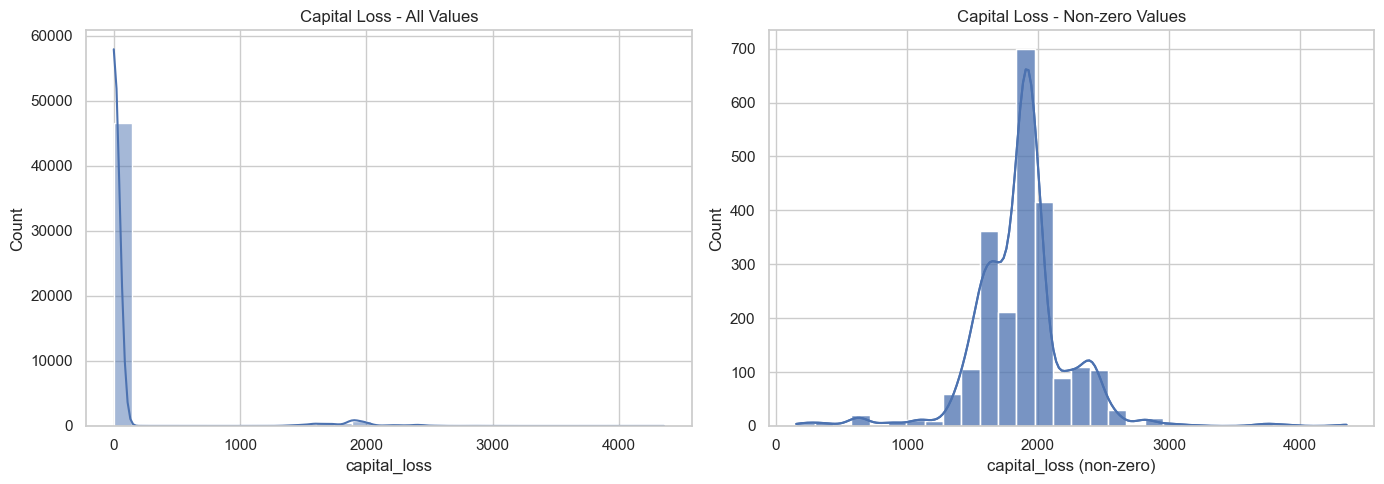

In [40]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# All values
sns.histplot(df_train_test['capital_loss'], bins=30, kde=True, ax=axes[0], color='#4c72b0')
axes[0].set_title('Capital Loss - All Values')
axes[0].set_xlabel('capital_loss')
axes[0].set_ylabel('Count')

# Non‑zero values
non_zero_gain = df_train_test[df_train_test['capital_loss'] > 0]['capital_loss']
ax = sns.histplot(non_zero_gain, bins=30, kde=True, ax=axes[1], color='#4c72b0')
sns.histplot(non_zero_gain, bins=30, kde=True, ax=axes[1])
axes[1].set_title('Capital Loss - Non-zero Values')
axes[1].set_xlabel('capital_loss (non-zero)')
axes[1].set_ylabel('Count')

plt.tight_layout()
plt.show()

<span style="color: blue;"><b> Capital loss is zero for 95.33% of individuals, Positive losses show a right-skewed distribution with peak around 2000 and a maximum of 4356, though much less extreme than capital gains.</b></span>

# Hours Per week Analysis

In [42]:
df_train_test['hours_per_week'].describe()

count    48813.000000
mean        40.425051
std         12.390954
min          1.000000
25%         40.000000
50%         40.000000
75%         45.000000
max         99.000000
Name: hours_per_week, dtype: float64

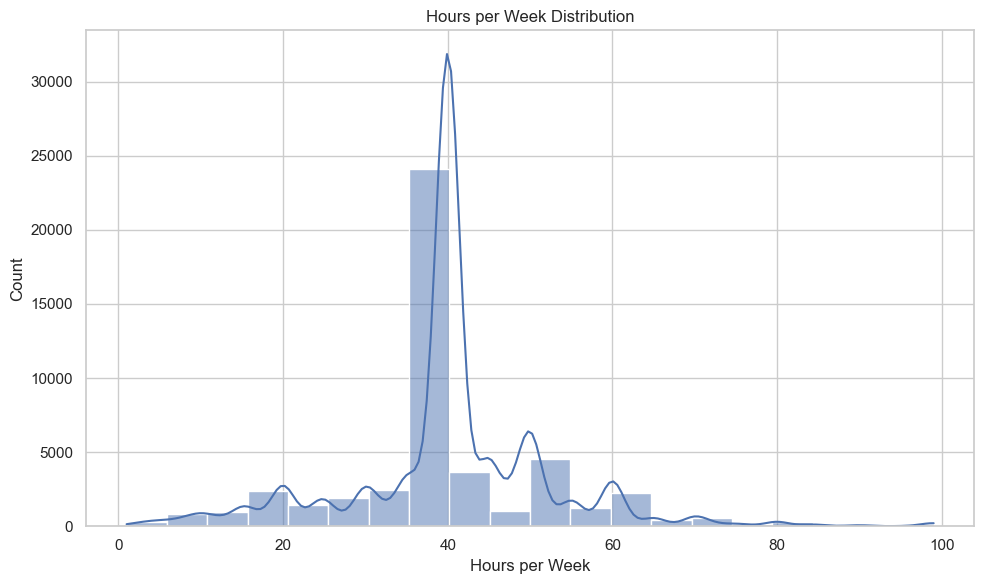

In [50]:
fig, ax = plt.subplots(1, 1, figsize=(10, 6))  # Single subplot

# Full distribution
sns.histplot(df_train_test['hours_per_week'], bins=20,  kde=True, color='#4c72b0', ax=ax)
ax.set_title('Hours per Week Distribution')
ax.set_xlabel('Hours per Week')
ax.set_ylabel('Count')

plt.tight_layout()
plt.show()


<span style="color: blue;">
Distribution centers tightly around standard 40-hour workweek (mean 40.4, median 40), with a peak at exactly 40 hours.
</span>
<span style="color: blue;">Clear right skew shows most work full-time hours, with smaller tails of part-time (<30) and overtime (>60) workers.</span>

# Native Country Analysis

In [53]:
# Cell 1: Basic exploration
print("Unique countries:", df_train_test['native_country'].nunique())
print("\nTop 10 countries:")
print(df_train_test['native_country'].value_counts().head(10))

Unique countries: 42

Top 10 countries:
native_country
United-States    43810
Mexico             947
Unknown            856
Philippines        295
Germany            206
Puerto-Rico        184
Canada             182
El-Salvador        155
India              151
Cuba               138
Name: count, dtype: int64


In [54]:
# Frequency table
country_counts = df_train_test['native_country'].value_counts()

print("Frequency Distribution:")
print(country_counts)

Frequency Distribution:
native_country
United-States                 43810
Mexico                          947
Unknown                         856
Philippines                     295
Germany                         206
Puerto-Rico                     184
Canada                          182
El-Salvador                     155
India                           151
Cuba                            138
England                         127
China                           122
South                           115
Jamaica                         106
Italy                           105
Dominican-Republic              103
Japan                            92
Poland                           87
Guatemala                        86
Vietnam                          86
Columbia                         85
Haiti                            75
Portugal                         67
Taiwan                           65
Iran                             59
Greece                           49
Nicaragua                

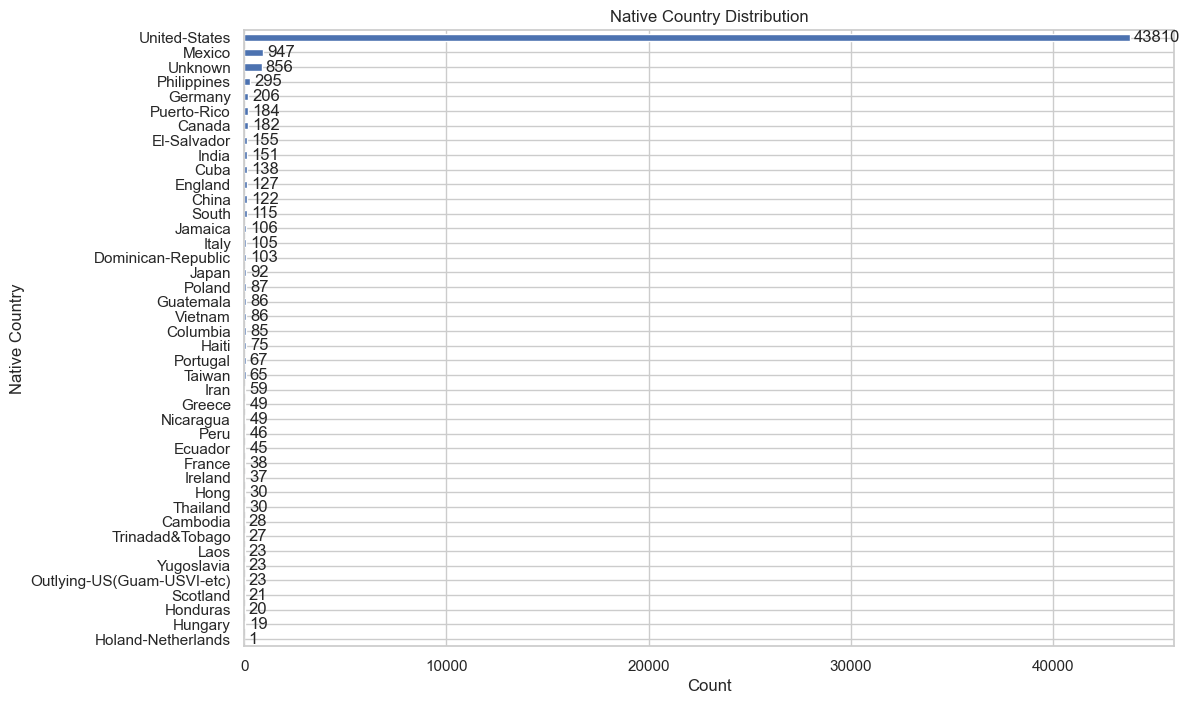

In [61]:

plt.figure(figsize=(12,8))

ax = country_counts.plot(kind='barh')

plt.title("Native Country Distribution")
plt.xlabel("Count")
plt.ylabel("Native Country")

plt.gca().invert_yaxis()  # Highest values at top

# Add value labels correctly
for container in ax.containers:
    ax.bar_label(container, fmt='%d', padding=3)
plt.show()

<span style="color: blue;">The native_country variable is highly imbalanced, with the majority of individuals originating from the United-States, while other countries have very low representation.</span>

# Target Variable : Income Analysis

In [62]:
# Frequency count
income_counts = df_train_test['income'].value_counts()

print("Frequency Distribution:")
print(income_counts)

Frequency Distribution:
income
<=50K    37128
>50K     11685
Name: count, dtype: int64


In [64]:
income_percent = df_train_test['income'].value_counts(normalize=True) * 100

print("Percentage Distribution:")
print(income_percent.round(2))

Percentage Distribution:
income
<=50K    76.06
>50K     23.94
Name: proportion, dtype: float64


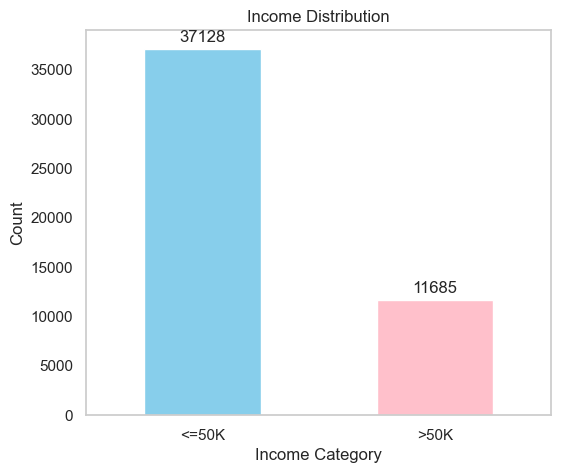

In [73]:

plt.figure(figsize=(6,5))

ax = income_counts.plot(kind='bar', color=['skyblue','pink'])

plt.title("Income Distribution")
plt.xlabel("Income Category")
plt.ylabel("Count")
plt.xticks(rotation=0)
plt.grid(False)

# Add labels on top
for container in ax.containers:
    ax.bar_label(container, fmt='%d', padding=3)

plt.show()

<span style="color: blue;">The income variable is imbalanced, with approximately 37,000 individuals earning ≤50K and around 11,700 earning >50K, showing a clear majority in the lower income category.</span>

The dataset shows distinct patterns across key features:  
- `native_country` is highly imbalanced, dominated by individuals from the United-States, with many rare countries representing less than 1% each.  
- The `income` variable is moderately imbalanced, with about 76% earning ≤50K and 24% earning >50K.  
- Numerical variables `capital_gain` and `capital_loss` are heavily right-skewed with most values at zero, indicating many individuals report no capital gains or losses.  
- `hours_per_week` centers around 40 hours with a roughly symmetric distribution, reflecting typical full-time work hours.